#  Práctica: Reconocimiento de dígitos con SVD

Vamos a usar la SVD para hacer un sistema de reconocimiento de los dígitos 0-9 manuscritos.  


La base de datos MNIST contiene 70000 imágenes en blanco y negro  de 28 x 28 pixels  
de dígitos del 0 al 9 escritos a mano. 

In [1]:
# cargamos la base datos MNIST desde scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist.data      # (70000, 784)
y = mnist.target    # labels como strings



Podemos ver las diez primeras imágenes:

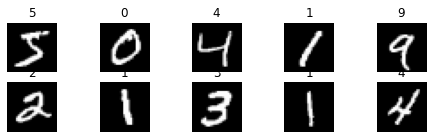

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(8, 2))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i, :].reshape(28, 28), cmap="gray")
    ax.set_title(y[i])
    ax.axis("off")

plt.show()


Escoge las $num_{train} = 100$ primeras imágenes de cada dígito como entrenamiento y las 1000 últimas  como test. El train_set será un tensor $T$ con shape (10, 784, 50)  
de forma que $T[i]$ contendrá 50 imágenes del dígito $i$. Harmos la traspuesta para poner las imágenes por columnas con lo que $T[i]$ es una matriz de tamaño $784\times 50$. De esta forma tenemos $50$ columnas y en cada una de esas $50$ columnas hay una imagen de $784$ pixeles.


In [3]:
# Completar aquí
num_train = 100  # cantidad de imágenes usadas para entrenar
T = np.zeros((10, 784, num_train))
#print(T[1].shape)

for i in range(10):
    idx = np.where(y == str(i))[0]   # índices con label "i"
    T[i, :, :] = X[idx[:num_train], :].T    # trasponemos para poner la imágenes en columnas
    

test_set = X[-1000:, :]  # imágenes para testear: filas de X
label_test = y[-1000:]   # labels de cada imagen como string. 

# Fin Completar aquí ------------------------------------

Muestra por pantalla los dígitos "promedio" haciendo la media de   
los vectores correspondientes.

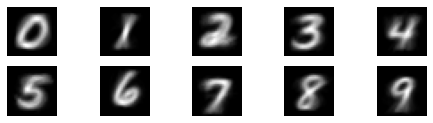

In [4]:
# Completar aquí

fig, axes = plt.subplots(2, 5, figsize=(8, 2))

for i, ax in enumerate(axes.flat):
    ax.imshow(T[i].mean(axis=1, keepdims=True).reshape(28, 28), cmap="gray")
    ax.axis("off")

plt.show()

# Fin Completar aquí ------------------------------------


El algoritmo o estrategia que utilizaremos para identificar cada uno de los dígitos es el siguiente:

1) Para cada $i=0,\dots,9$, haremos la factorización SVD de la matriz $T[i]=U\Sigma V^{\top}$.  

2) Como sabemos, las columnas de $U$ son una base ortonormal del subespacio de columnas  
de $T[i]$. Tomaremos solo las (**nb**)-primeras que generarán un subespacio  $U_i$. Recordemos que las columnas de $T[i]$ contienen las imágenes. Por tanto,  los vectores singulares izquierdos pueden interpretarse como patrones básicos de imagen: trazos, zonas oscuras y claras, formas típicas del dígito, etc. En efecto, recordemos también que 
$\text{Col}(T[i])$ es el subsepacio generado por los vectores singulares por la izquierda asociados a valores singulares no nulos. No es necesario quedarse con todos los vectores singulares. Es suficiente tomar los más representativos, es decir, los asociados a los vectores singulares más grandes. Por tanto, el subespacio $U_i$ caracteriza o aproxima al dígito $i$-ésimo.

3) Dada una imagen $x$ que queremos identificar, calcularemos la distancia $d_i$ de $x$ a la   proyección ortogonal de $x$ sobre cada subespacio $U_i$. Si el mínimo de estas distancias se produce en $d_j$, identificaremos $x$ con el dígito $j$ ya que eso signífica que la imagen $x$ está más cerca del subespacio $U_j$. Por tanto, debe parecerse al dígito $j$.

Veamos cómo calcular estas distancias. Si $U_i=\langle u_1,\dots, u_{nd}\rangle$ y ponemos los vectores $u_j$  
como columnas de una matriz $B$, la proyección de $x$ sobre $U_i$ es $BB^{\top}x$. En efecto: el producto  
$B^{\top}x$ nos da las coordenadas de $x$ en la base $\{u_1,\dots, u_{nd}\}$, puesto que estas son  
el producto escalar de $x$ con cada $u_j$ al ser una base ortonormal. Al multiplicar después por $B$  
calculamos la combinación lineal de la base (columnas de $B$) con esos coeficientes.


Vayamos por partes:

1) Toma **nb=10**, carga el método **svd** y define los siguientes tres tensores:

(a) $B$, tensor nulo, y de dimensiones $10\times 784\times nb$,

(b) $U$, tensor nulo, y de dimensiones $10\times 784\times 784$,

(c) $V_t$, tensor nulo, y de dimensiones $10\times num_{train} \times num_{train}$.

2) Define también una matriz $s$ de dimensiones $10\times num_{train}$.


In [5]:
# Completar aquí

from scipy.linalg import svd
nb = 10   # tomamos los primeros nb vectores singulares por la izquierda

B = np.zeros((10, 784, nb))
U = np.zeros((10, 784, 784))
s = np.zeros((10, num_train))
Vt = np.zeros((10, num_train, num_train))

# Fin Completar aquí

Haz un bucle **for** recorriendo los $10$ dígitos donde en cada paso del bucle calcules 
la factorización SVD de la matriz $T[i]$ y almacena los vectores singulares por la izquierda en $U[i]$, los vectores singulares en $s[i]$, y los vectores singulares por la derecha en $V_t[i]$. Finalmente, guarda en la matriz $B[i]$, los $nb$ primeros vectores singulares por la izquierda.  

In [6]:
# Completar aquí

for i in range(10):
    U[i], s[i], Vt[i] = svd(T[i])  # calculamos la SVD para cada dígito
    B[i] = U[i, :, :nb]            # seleccionamos los 10 primeros vectores singulares

# Fin Completar aquí


El siguiente trozo de código toma imágenes del conjunto de datos test, calcula la distancia a cada subespacio $U_i$ y, en función de dichas distancias, clasifica el dígito correspondiente.

In [7]:
# Completar aquí
    
label_test = label_test.astype(int) # pasamos las etiquetas a enteros
count = 0                           # contador del número de aciertos
dist = np.zeros(10)                 # vector que guardará las distancias a los U_i

for num in range(test_set.shape[0]):
    u = test_set[num, :]
    u_label = label_test[num]

    for i in range(10):
        dist[i] = np.linalg.norm(u - B[i] @ B[i].T @ u)
    
    idx_min = np.argmin(dist)
    
    if idx_min == u_label:
        count += 1
        
        
print(f"El porcentaje de aciertos es {count/10} %")




El porcentaje de aciertos es 92.4 %
